# Projet OpenClassrooms — Requêtez des services IA

Notebook adapté pour exécution **locale Windows** (PowerShell + `uv`) et appel à l'API serverless Hugging Face.

## 1. Configuration Initiale et Importations

Commençons par importer les bibliothèques Python nécessaires. Nous aurons besoin de :
- `os` pour interagir avec le système de fichiers (lister les images).
- `requests` pour effectuer des requêtes HTTP vers l'API.
- `PIL (Pillow)` pour manipuler les images.
- `matplotlib.pyplot` pour afficher les images et les masques.
- `numpy` pour la manipulation des tableaux (les images sont des tableaux de pixels).
- `tqdm.notebook` pour afficher une barre de progression (utile pour plusieurs images).
- `base64` et `io` pour décoder les masques renvoyés par l'API.

In [1]:
import os
import re
import io
import base64
import time
import statistics
from pathlib import Path

import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from dotenv import load_dotenv
from tqdm.notebook import tqdm


### Variables de Configuration

Nous devons définir quelques variables :
- `image_dir`: Le chemin vers le dossier contenant vos images. **Assurez-vous de modifier ce chemin si nécessaire.**
- `max_images`: Le nombre maximum d'images à traiter (pour ne pas surcharger l'API ou attendre trop longtemps).
- `api_token`: Votre jeton d'API Hugging Face. **IMPORTANT : Gardez ce jeton secret !**

**Comment obtenir un token API Hugging Face ?**
1. Créez un compte sur [huggingface.co](https://huggingface.co/).
2. Allez dans votre profil -> Settings -> Access Tokens.
3. Créez un nouveau token (par exemple, avec le rôle "read").
4. Copiez ce token ici.

In [2]:
# ✅ Configuration (Windows / uv / exécution locale)
# Arborescence attendue :
# data/
#   images/   -> image_0.png, image_1.png, ...
#   mask/     -> mask_0.png, mask_1.png, ...  (ground truth)

IMG_DIR = Path("data/images")
GT_MASK_DIR = Path("data/mask")

# Nombre d'images à tester (commence petit, puis augmente)
MAX_IMAGES = 3

# Modèle Hugging Face imposé par le projet
MODEL_ID = "sayeed99/segformer_b3_clothes"

# Token HF (dans un fichier .env à la racine : HF_TOKEN=hf_...)
load_dotenv()
HF_TOKEN = os.getenv("HF_TOKEN")
assert HF_TOKEN, "HF_TOKEN manquant. Crée un fichier .env avec HF_TOKEN=hf_..."

# Endpoint serverless HF Inference API
API_URL = f"https://api-inference.huggingface.co/models/{MODEL_ID}"
HEADERS = {"Authorization": f"Bearer {HF_TOKEN}"}

# Vérifs dossiers
assert IMG_DIR.exists(), f"Dossier introuvable: {IMG_DIR.resolve()}"
assert GT_MASK_DIR.exists(), f"Dossier introuvable: {GT_MASK_DIR.resolve()}"

print("✅ Config OK")
print("MODEL_ID:", MODEL_ID)
print("API_URL :", API_URL)
print("Images  :", IMG_DIR.resolve())
print("GT masks:", GT_MASK_DIR.resolve())


✅ Config OK
MODEL_ID: sayeed99/segformer_b3_clothes
API_URL : https://api-inference.huggingface.co/models/sayeed99/segformer_b3_clothes
Images  : C:\Users\Shadow\Documents\OC\PROJET2\RENDU\data\images
GT masks: C:\Users\Shadow\Documents\OC\PROJET2\RENDU\data\mask


## 2. Comprendre l'API d'Inférence Hugging Face

L'API d'inférence permet d'utiliser des modèles hébergés sur Hugging Face sans avoir à les télécharger ou à gérer l'infrastructure.

- **Modèle utilisé** : Nous allons utiliser le modèle `sayeed99/segformer_b3_clothes`, spécialisé dans la segmentation de vêtements et de parties du corps.
- **URL de l'API** : L'URL pour un modèle est généralement `https://api-inference.huggingface.co/models/NOM_DU_MODELE`.
- **Headers (En-têtes)** : Pour s'authentifier et spécifier le type de contenu, nous envoyons des en-têtes avec notre requête.
    - `Authorization`: Contient notre token API (précédé de `Bearer `).
    - `Content-Type`: Indique que nous envoyons une image au format JPEG (ou PNG selon le cas).

In [3]:
# ✅ Préparer la liste des images à traiter + associer le GT mask correspondant
# Ici, on associe par index : image_0.png <-> mask_0.png

def extract_index(filename: str) -> int:
    m = re.search(r"_(\d+)\.", filename)
    if not m:
        raise ValueError(f"Index introuvable dans: {filename}")
    return int(m.group(1))

image_paths = sorted(list(IMG_DIR.glob("image_*.png")))
gt_mask_paths = sorted(list(GT_MASK_DIR.glob("mask_*.png")))

print("Images trouvées:", len(image_paths))
print("Masks GT trouvés:", len(gt_mask_paths))

img_by_idx = {extract_index(p.name): p for p in image_paths}
gt_by_idx = {extract_index(p.name): p for p in gt_mask_paths}

common_idx = sorted(set(img_by_idx.keys()) & set(gt_by_idx.keys()))
pairs = [(img_by_idx[i], gt_by_idx[i]) for i in common_idx]

print("Paires image/GT:", len(pairs))
print("Exemple paire:", pairs[0][0].name, "<->", pairs[0][1].name if pairs else None)

# Limiter pour les tests
pairs = pairs[:MAX_IMAGES]


Images trouvées: 50
Masks GT trouvés: 50
Paires image/GT: 50
Exemple paire: image_0.png <-> mask_0.png


## 3. Fonctions Utilitaires pour le Traitement des Masques

Le modèle que nous utilisons (`sayeed99/segformer_b3_clothes`) renvoie des masques pour différentes classes (cheveux, chapeau, etc.). Ces masques sont encodés en base64. Les fonctions ci-dessous sont fournies pour vous aider à :
1.  `CLASS_MAPPING`: Un dictionnaire qui associe les noms de classes (ex: "Hat") à des identifiants numériques.
2.  `get_image_dimensions`: Récupérer les dimensions d'une image.
3.  `decode_base64_mask`: Décoder un masque de base64 en une image (tableau NumPy) et le redimensionner.
4.  `create_masks`: Combiner les masques de toutes les classes détectées en un seul masque de segmentation final, où chaque pixel a la valeur de l'ID de sa classe.

**Cette partie est donnée car elle est spécifique au format de sortie de ce modèle et un peu complexe pour une première approche.** Lisez-la pour comprendre son rôle, mais ne vous attardez pas sur les détails d'implémentation pour l'instant.

In [4]:
CLASS_MAPPING = {
    "Background": 0,
    "Hat": 1,
    "Hair": 2,
    "Sunglasses": 3,
    "Upper-clothes": 4,
    "Skirt": 5,
    "Pants": 6,
    "Dress": 7,
    "Belt": 8,
    "Left-shoe": 9,
    "Right-shoe": 10,
    "Face": 11,
    "Left-leg": 12,
    "Right-leg": 13,
    "Left-arm": 14,
    "Right-arm": 15,
    "Bag": 16,
    "Scarf": 17
}

def get_image_dimensions(img_path):
    """
    Get the dimensions of an image.

    Args:
        img_path (str): Path to the image.

    Returns:
        tuple: (width, height) of the image.
    """
    original_image = Image.open(img_path)
    return original_image.size

def decode_base64_mask(base64_string, width, height):
    """
    Decode a base64-encoded mask into a NumPy array.

    Args:
        base64_string (str): Base64-encoded mask.
        width (int): Target width.
        height (int): Target height.

    Returns:
        np.ndarray: Single-channel mask array.
    """
    mask_data = base64.b64decode(base64_string)
    mask_image = Image.open(io.BytesIO(mask_data))
    mask_array = np.array(mask_image)
    if len(mask_array.shape) == 3:
        mask_array = mask_array[:, :, 0]  # Take first channel if RGB
    mask_image = Image.fromarray(mask_array).resize((width, height), Image.NEAREST)
    return np.array(mask_image)

def create_masks(results, width, height):
    """
    Combine multiple class masks into a single segmentation mask.

    Args:
        results (list): List of dictionaries with 'label' and 'mask' keys.
        width (int): Target width.
        height (int): Target height.

    Returns:
        np.ndarray: Combined segmentation mask with class indices.
    """
    combined_mask = np.zeros((height, width), dtype=np.uint8)  # Initialize with Background (0)

    # Process non-Background masks first
    for result in results:
        label = result['label']
        class_id = CLASS_MAPPING.get(label, 0)
        if class_id == 0:  # Skip Background
            continue
        mask_array = decode_base64_mask(result['mask'], width, height)
        combined_mask[mask_array > 0] = class_id

    # Process Background last to ensure it doesn't overwrite other classes unnecessarily
    # (Though the model usually provides non-overlapping masks for distinct classes other than background)
    for result in results:
        if result['label'] == 'Background':
            mask_array = decode_base64_mask(result['mask'], width, height)
            # Apply background only where no other class has been assigned yet
            # This logic might need adjustment based on how the model defines 'Background'
            # For this model, it seems safer to just let non-background overwrite it first.
            # A simple application like this should be fine: if Background mask says pixel is BG, set it to 0.
            # However, a more robust way might be to only set to background if combined_mask is still 0 (initial value)
            combined_mask[mask_array > 0] = 0 # Class ID for Background is 0

    return combined_mask

In [5]:
# ✅ Helpers : appel API + décodage des masques

def hf_image_segmentation(image_path: Path, timeout_s: int = 60):
    """Appel HF Inference via le nouveau router (remplace l'ancien api-inference.* qui renvoie 410)."""
    api_url = f"https://router.huggingface.co/hf-inference/models/{MODEL_ID}"
    headers = {
        "Authorization": f"Bearer {HF_TOKEN}",
        # pour envoyer une image en binaire
        "Content-Type": "application/octet-stream",
        "Accept": "application/json",
    }
    with open(image_path, "rb") as f:
        data = f.read()
    resp = requests.post(api_url, headers=headers, data=data, timeout=timeout_s)
    if resp.status_code != 200:
        raise RuntimeError(f"HF API error {resp.status_code}: {resp.text[:500]}")
    return resp.json()

def decode_mask_to_np(mask_field) -> np.ndarray:
    """Convertit le champ 'mask' renvoyé par HF en array numpy 2D (0/255)."""
    # Cas le plus fréquent : base64 d'un PNG
    if isinstance(mask_field, str):
        raw = base64.b64decode(mask_field)
        img = Image.open(io.BytesIO(raw)).convert("L")
        return np.array(img)
    # Parfois HF renvoie déjà une image PIL (rare ici), ou bytes
    if isinstance(mask_field, bytes):
        img = Image.open(io.BytesIO(mask_field)).convert("L")
        return np.array(img)
    if isinstance(mask_field, Image.Image):
        return np.array(mask_field.convert("L"))
    raise TypeError(f"Format de mask non supporté: {type(mask_field)}")

def build_multiclass_pred_mask(api_output, target_size: tuple[int,int]):
    """Fusionne la sortie HF (liste de segments label/score/mask) en un masque multi-classes.

    - target_size = (W,H) de l'image originale
    - On remplit un masque 2D avec l'id de classe selon CLASS_MAPPING.
    - En cas de chevauchement, on garde le segment au meilleur score (ordre décroissant).
    """
    W, H = target_size
    pred = np.zeros((H, W), dtype=np.uint8)

    if not isinstance(api_output, list):
        return pred

    # Trier par score décroissant pour prioriser les segments les plus confiants
    api_output_sorted = sorted(api_output, key=lambda x: x.get("score", 0), reverse=True)

    for item in api_output_sorted:
        label = item.get("label")
        if label not in CLASS_MAPPING:
            continue
        class_id = CLASS_MAPPING[label]
        mask_field = item.get("mask")
        if mask_field is None:
            continue
        m = decode_mask_to_np(mask_field)

        # Mise à la taille si nécessaire
        if m.shape[0] != H or m.shape[1] != W:
            m = np.array(Image.fromarray(m).resize((W, H), resample=Image.NEAREST))

        # Le masque est souvent 0/255 (ou 0/1). On le binarise.
        m_bin = (m > 127)

        # On assigne la classe aux pixels True qui ne sont pas encore assignés
        pred[m_bin & (pred == 0)] = class_id

    return pred

def load_image_rgb(path: Path) -> Image.Image:
    return Image.open(path).convert("RGB")

def load_gt_mask(path: Path) -> np.ndarray:
    # GT mask : souvent une image en niveaux de gris avec ids (0..N) ou binaire
    return np.array(Image.open(path))


## 4. Segmentation d'une Seule Image

Avant de traiter toutes les images, concentrons-nous sur une seule pour bien comprendre le processus.

Étapes :
1.  Choisir une image.
2.  Ouvrir l'image en mode binaire (`"rb"`) et lire son contenu (`data`).
3.  Déterminer le `Content-Type` (par exemple, `"image/jpeg"` ou `"image/png"`).
4.  Envoyer la requête POST à l'API avec `requests.post()` en passant l'URL, les headers et les données.
5.  Vérifier le code de statut de la réponse. Une erreur sera levée si le code n'est pas 2xx (succès) grâce à `response.raise_for_status()`.
6.  Convertir la réponse JSON en un dictionnaire Python avec `response.json()`.
7.  Utiliser nos fonctions `get_image_dimensions` et `create_masks` pour obtenir le masque final.
8.  Afficher l'image originale et le masque segmenté.

Image: image_0.png size: (400, 600)
GT  : mask_0.png shape: (600, 400) unique: [ 0  2  4  6  9 10 11 12 13 15 16]
Nb segments HF: 11
Pred mask unique: [ 0  2  4  6  9 10 11 12 13 15 16]


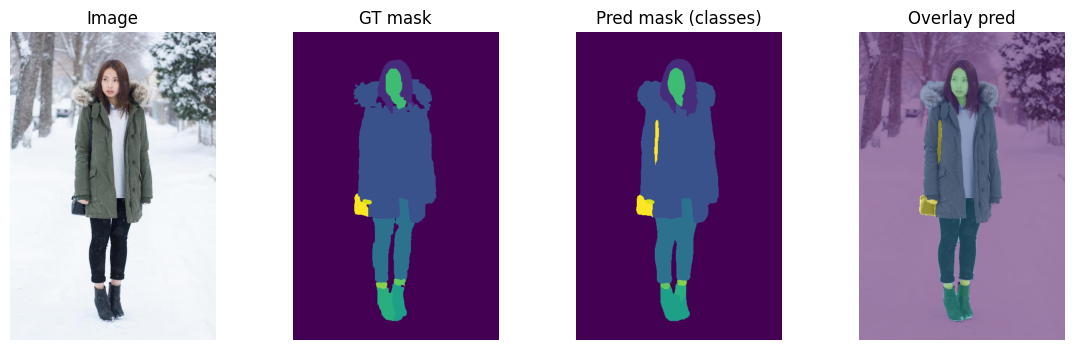

In [6]:
# ✅ Test sur 1 paire (image + GT mask) + sortie API brute

assert pairs, "Aucune paire image/GT trouvée. Vérifie data/images et data/mask."

img_path, gt_path = pairs[0]

img = load_image_rgb(img_path)
W, H = img.size
gt = load_gt_mask(gt_path)

print("Image:", img_path.name, "size:", (W,H))
print("GT  :", gt_path.name, "shape:", gt.shape, "unique:", np.unique(gt)[:20])

# Appel API
api_out = hf_image_segmentation(img_path)
print("Nb segments HF:", len(api_out) if isinstance(api_out, list) else type(api_out))

# Construire un masque préd multi-classes
pred_mask = build_multiclass_pred_mask(api_out, target_size=(W,H))
print("Pred mask unique:", np.unique(pred_mask)[:20])

# Visualisation (image, GT, pred, overlays)
plt.figure(figsize=(14,4))

plt.subplot(1,4,1)
plt.imshow(img); plt.axis("off"); plt.title("Image")

plt.subplot(1,4,2)
plt.imshow(gt); plt.axis("off"); plt.title("GT mask")

plt.subplot(1,4,3)
plt.imshow(pred_mask); plt.axis("off"); plt.title("Pred mask (classes)")

plt.subplot(1,4,4)
plt.imshow(img)
plt.imshow(pred_mask, alpha=0.5)
plt.axis("off"); plt.title("Overlay pred")
plt.show()

# Aperçu labels + scores
if isinstance(api_out, list):
    [(x.get("label"), round(x.get("score",0),3)) for x in api_out[:10]]


## 5. Segmentation de Plusieurs Images (Batch)

Maintenant que nous savons comment traiter une image, nous pouvons créer une fonction pour en traiter plusieurs.
Cette fonction va boucler sur la liste `image_paths` et appliquer la logique de segmentation à chaque image.
Nous utiliserons `tqdm` pour avoir une barre de progression.

In [7]:
def segment_images_batch(pairs_list):
    """Segmente une liste de paires (image_path, gt_mask_path) via HF.

    Retour:
      - results: liste de dicts {image, gt_path, api_out, pred_mask, latency_s}
    """
    results = []
    for img_path, gt_path in tqdm(pairs_list, desc="Segmentation HF"):
        img = load_image_rgb(img_path)
        W, H = img.size

        t0 = time.perf_counter()
        api_out = hf_image_segmentation(img_path)
        latency = time.perf_counter() - t0

        pred_mask = build_multiclass_pred_mask(api_out, target_size=(W,H))

        results.append({
            "image_path": img_path,
            "gt_path": gt_path,
            "api_out": api_out,
            "pred_mask": pred_mask,
            "latency_s": latency,
        })
    return results

batch_results = segment_images_batch(pairs)
print("✅ Batch terminé. Nb items:", len(batch_results))


Segmentation HF:   0%|          | 0/3 [00:00<?, ?it/s]

✅ Batch terminé. Nb items: 3


## 6. Affichage des Résultats en Batch

Nous allons maintenant créer une fonction pour afficher les images originales et leurs segmentations correspondantes côte à côte, dans une grille.

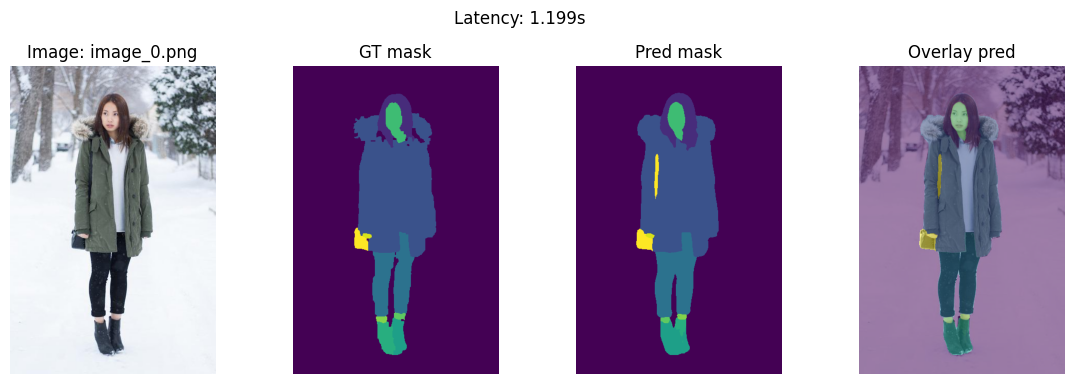

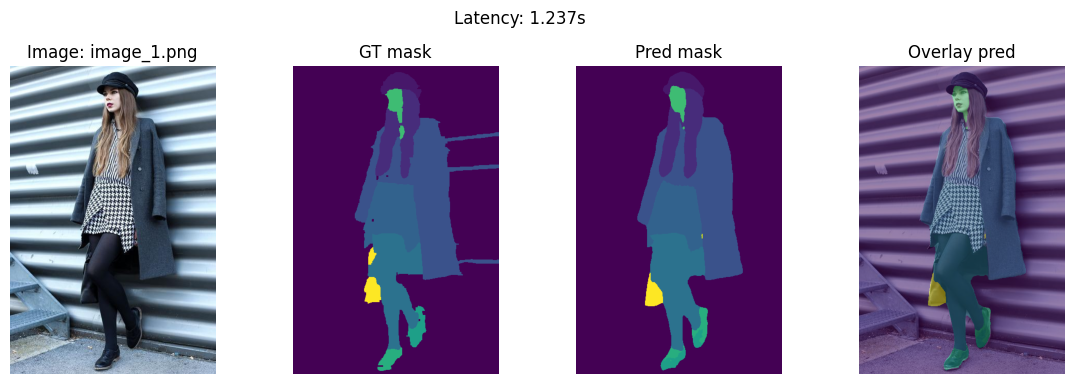

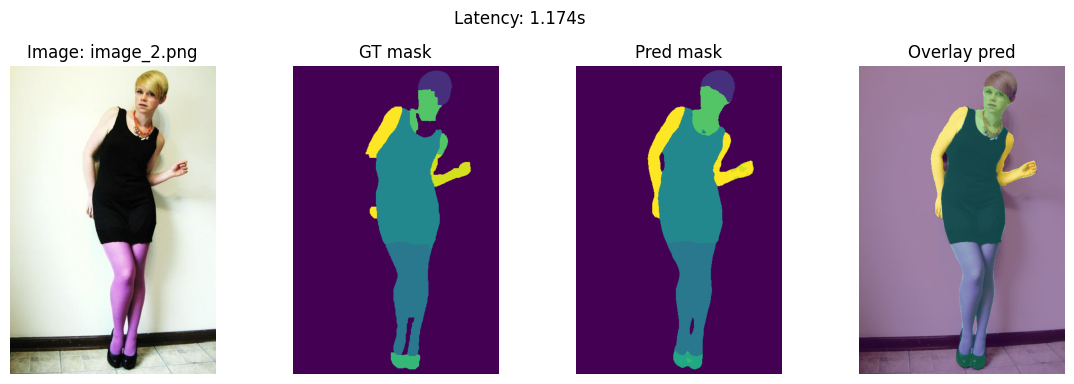

In [8]:
def display_segmented_images_batch(batch_results, max_show=3):
    """Affiche image + GT + prédiction pour quelques éléments."""
    for r in batch_results[:max_show]:
        img = load_image_rgb(r["image_path"])
        gt = load_gt_mask(r["gt_path"])
        pred = r["pred_mask"]

        plt.figure(figsize=(14,4))
        plt.subplot(1,4,1); plt.imshow(img); plt.axis("off"); plt.title(f'Image: {r["image_path"].name}')
        plt.subplot(1,4,2); plt.imshow(gt); plt.axis("off"); plt.title("GT mask")
        plt.subplot(1,4,3); plt.imshow(pred); plt.axis("off"); plt.title("Pred mask")
        plt.subplot(1,4,4); plt.imshow(img); plt.imshow(pred, alpha=0.5); plt.axis("off"); plt.title("Overlay pred")
        plt.suptitle(f'Latency: {r["latency_s"]:.3f}s', y=1.02)
        plt.show()

display_segmented_images_batch(batch_results, max_show=min(3, len(batch_results)))


In [9]:
# ✅ Évaluation simple (IoU global hors background)
# Hypothèse: GT mask et pred_mask utilisent les mêmes ids de classes (0=background).
# Si ton GT est binaire (0/255), on le convertit en 0/1 et on compare au pred != 0.

def to_binary_mask(arr: np.ndarray) -> np.ndarray:
    if arr.dtype != np.bool_:
        # Si valeurs 0/255 ou 0..N
        return (arr > 0)
    return arr

def iou_binary(a: np.ndarray, b: np.ndarray) -> float:
    inter = np.logical_and(a, b).sum()
    union = np.logical_or(a, b).sum()
    return float(inter / union) if union > 0 else 1.0

rows = []
for r in batch_results:
    gt = load_gt_mask(r["gt_path"])
    pred = r["pred_mask"]

    gt_bin = to_binary_mask(gt)
    pred_bin = to_binary_mask(pred)

    iou = iou_binary(gt_bin, pred_bin)
    rows.append({
        "image": r["image_path"].name,
        "latency_s": r["latency_s"],
        "iou_binary": iou
    })

df_metrics = pd.DataFrame(rows)
df_metrics


,image,latency_s,iou_binary
0,image_0.png,1.199292,0.951030
1,image_1.png,1.237244,0.923826
2,image_2.png,1.173977,0.908027


In [10]:
# ✅ Performance + estimation coût (500 000 images / 30 jours)

avg_latency = df_metrics["latency_s"].mean()
p90_latency = df_metrics["latency_s"].quantile(0.9)

print(f"Latence moyenne: {avg_latency:.3f}s | p90: {p90_latency:.3f}s")

NB_IMAGES = 500_000

# ⚠️ Hypothèse: prix équivalent $/heure compute (à adapter selon ton plan/pricing retenu)
PRICE_PER_HOUR = 0.06  # exemple
price_per_second = PRICE_PER_HOUR / 3600

total_cost = NB_IMAGES * avg_latency * price_per_second
cost_per_day = total_cost / 30
cost_per_1000 = 1000 * avg_latency * price_per_second

print(f"Coût total (500k/30j): {total_cost:.2f} $")
print(f"Coût / jour: {cost_per_day:.2f} $")
print(f"Coût / 1000 images: {cost_per_1000:.4f} $")


Latence moyenne: 1.204s | p90: 1.230s
Coût total (500k/30j): 10.03 $
Coût / jour: 0.33 $
Coût / 1000 images: 0.0201 $


## Conclusion et Prochaines Étapes

Félicitations ! Vous avez appris à :
- Configurer les appels à l'API d'inférence Hugging Face.
- Envoyer des images pour la segmentation.
- Interpréter les résultats (avec l'aide des fonctions fournies).
- Visualiser les segmentations.

Pistes d'amélioration ou d'exploration :
- **Gestion d'erreurs plus fine** : Implémenter des tentatives multiples (retry) en cas d'échec de l'API (par exemple, si le modèle est en cours de chargement).
- **Appels asynchrones** : Pour un grand nombre d'images, des appels asynchrones (avec `asyncio` et `aiohttp`) seraient beaucoup plus rapides.
- **Autres modèles** : Explorer d'autres modèles de segmentation ou d'autres tâches sur Hugging Face Hub.

N'hésitez pas à modifier le code, à tester avec vos propres images et à explorer davantage !

**_Note_** : Si vous aimez ce modèle, n'hésitez pas à le [télécharger](https://huggingface.co/sayeed99/segformer_b3_clothes) et jouer avec directement sur votre machine !